# Reconstructing the past: estimating solar radio flux F10.7 from sunspot records
## Roman Branovets, Skoltech, 2025

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In this assignment we need to predict data of radio in the past based on finding a dependence on another parameter.

Loading data from files

In [2]:
data_sol=np.loadtxt("Sunspot_number_monthly_mean.txt")
data_radio = np.loadtxt("Radio_flux_monthly_mean.txt")

Plot graphs of the number of sunspots and the amount of radiation for the entire available period.

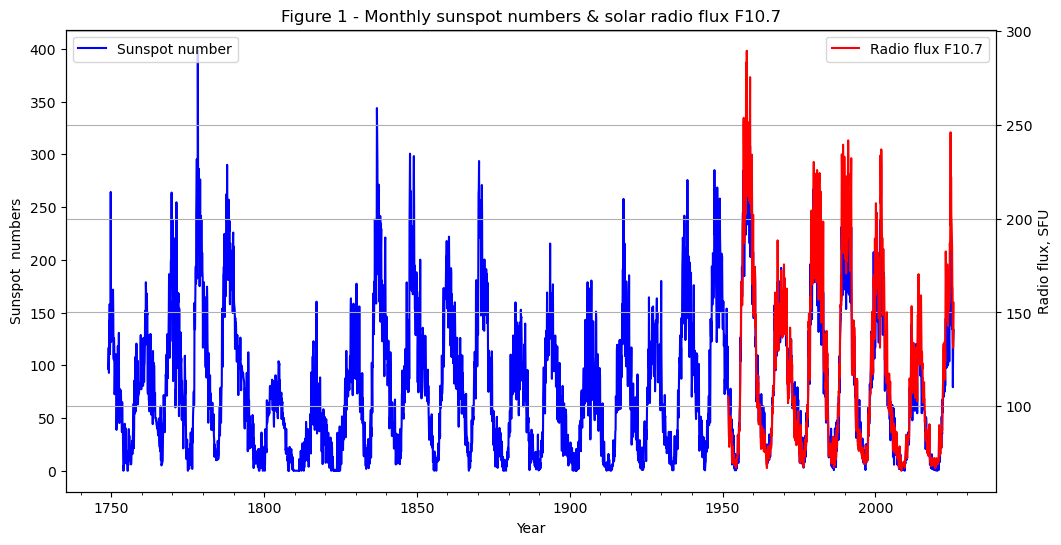

In [3]:
# plot of monthly sunspot numbers & solar radio flux F10.7
dates_sol = [datetime(int(year), int(month), 1) for year, month in zip(data_sol[:,0].astype(int), data_sol[:,1].astype(int))]
dates_rad = [datetime(int(year), int(month), 1) for year, month in zip(data_radio[:,0].astype(int), data_radio[:,1].astype(int))]
plt.figure(figsize=(12,6))
plt.plot(dates_sol,data_sol[:,2],color='blue',label='Sunspot number')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(50))    
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(10))    
plt.title('Figure 1 - Monthly sunspot numbers & solar radio flux F10.7')
plt.xlabel('Year')
plt.ylabel('Sunspot  numbers')
plt.legend(loc='upper left')
ax2 = plt.gca().twinx()
ax2.plot(dates_rad,data_radio[:,2],color='red', label='Radio flux F10.7')
ax2.set_ylabel('Radio flux, SFU')
ax2.legend(loc='upper right')
plt.grid()
plt.show()

As we can see, the data is noisy. Therefore, we will use the running mean method to smooth the graph.

13-month running mean function
13-month running mean R

$$R = \frac{1}{24} R_{i-6} + \frac{1}{12}(R_{i-5} + R_{i-4} + R_{i-3} + R_{i-2} + R_{i-1} + R_i + R_{i+1} + R_{i+2} + R_{i+3} + R_{i+4} + R_{i+5}) + \frac{1}{24} R_{i+6}$$

For the first six months of available data, the values are averaged to obtain the smoothed
estimates. The same applies to the last six months of data.

In [4]:
def mean_13(data):
    data_clean=np.array(data)
    firstmean= sum(data_clean[:6, 2]) / 6
    lastmean = sum(data_clean[-6:, 2]) / 6
    for i in range(6,data_clean.shape[0]-6):
        data_clean[i,2]=(1/24)*data[i-6,2]+(1/12)*(np.sum(data[i-5:i+6,2]))+(1/24)*data[i+6,2]
    data_clean[:6, 2] = firstmean
    data_clean[-6:, 2] = lastmean
    return data_clean

Applying this function and build smoother graphs.

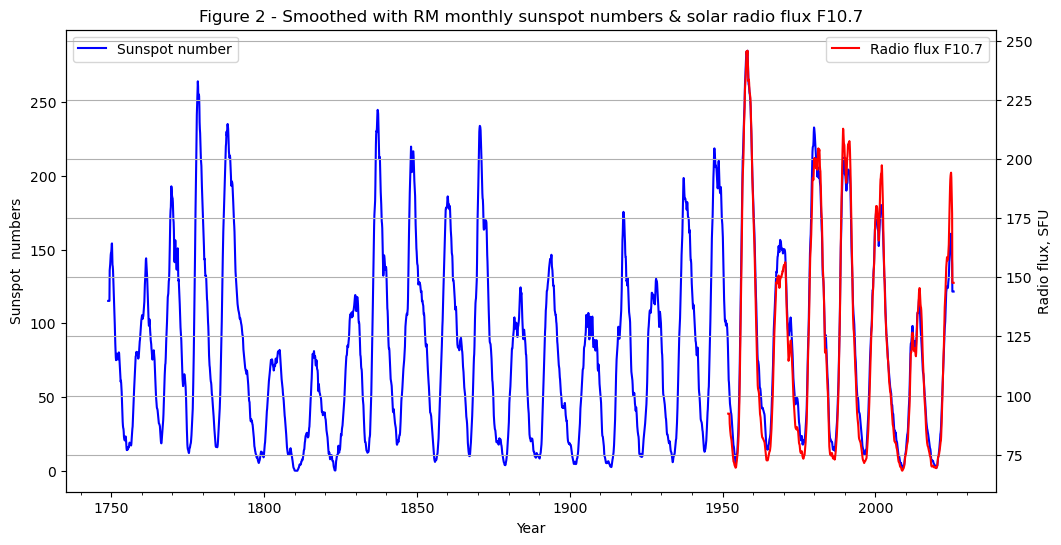

In [5]:
data_sol_clear=mean_13(data_sol)
data_radio_clear=mean_13(data_radio)
# plot of smoothed with RM monthly sunspot numbers & solar radio flux F10.7
plt.figure(figsize=(12,6))
plt.plot(dates_sol,data_sol_clear[:,2],color='blue',label='Sunspot number')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(50))    
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(10))    
plt.legend(loc='upper left')
plt.title('Figure 2 - Smoothed with RM monthly sunspot numbers & solar radio flux F10.7')
plt.xlabel('Year')
plt.ylabel('Sunspot  numbers')
ax2 = plt.gca().twinx()
ax2.plot(dates_rad,data_radio_clear[:,2],color='red', label='Radio flux F10.7')
ax2.set_ylabel('Radio flux, SFU')
ax2.legend(loc='upper right')
plt.grid()
plt.show()

After applying this method we have got more smoothed data. 

Let's find the time interval at which we have both values, so that we can use it to train the linear regression model. So, we can make a scatter plot.

Creating a scatter plot

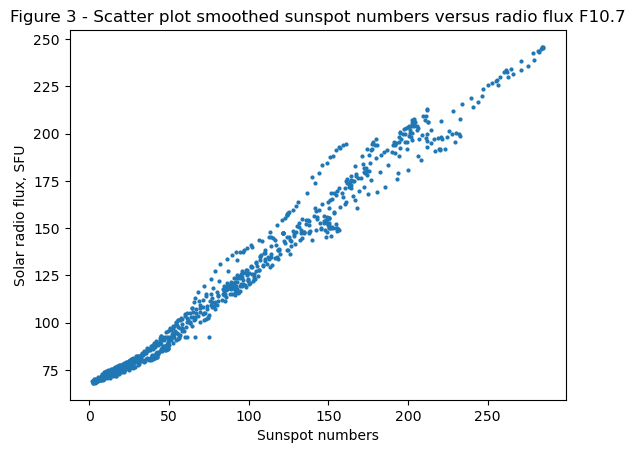

In [6]:
# scatter plot of smoothed monthly sunspot numbers & solar radio flux F10.7
plt.scatter(data_sol_clear[2434:,2],data_radio_clear[:,2], 4)
plt.xlabel('Sunspot numbers')
plt.ylabel('Solar radio flux, SFU')
plt.title('Figure 3 - Scatter plot smoothed sunspot numbers versus radio flux F10.7')
plt.show()

We see a clear dependence that with the growth of the sunspot number, solar radio flux is growing. It can be concluded that the values depend on each other.

To achieve greater accuracy, we will use the Multi-dimensional linear regression model.

Multi-dimensional linear regression model:

$$F_i = \beta_0 + \beta_1 R_i^2 + \beta_2 R_i^2 + \beta_3 R_i^3 + \epsilon_i \tag{1}$$

Where,

- $F$ is vector of dependent variables (regressand), representing the smoothed solar radio flux at 10.7 cm.
  $$F = 
  \begin{vmatrix}
    f_1 \\
    f_2 \\
    \vdots \\
    f_N
  \end{vmatrix}$$
  and $f_1, f_2, f_N$ is flux at different times.

- $R$ is matrix of independent variables (regressors)
  $$R = 
  \begin{vmatrix}
    1 & r_1 & r_1^2 & r_1^3 \\
    1 & r_2 & r_2^2 & r_2^3 \\
    \vdots & \vdots & \vdots & \vdots \\
    1 & r_N & r_N^2 & r_N^3
  \end{vmatrix}$$
  and $r_1, r_2, \ldots, r_N$ are the smoothed sunspot numbers at different times.


- $\beta$ is vector of coefficients to be estimated
  $$\beta = 
  \begin{vmatrix}
    \beta_0 \\
    \beta_1 \\
    \beta_2 \\
    \beta_3
  \end{vmatrix}$$

- $\epsilon_i$ is error term

In [7]:
n=data_radio_clear.shape[0]
# r_train is matrix of independent variables
r_train=np.ones((n,4))
r_train[:,1]=data_sol_clear[2434:,2]
r_train[:,2]=data_sol_clear[2434:,2]**2
r_train[:,3]=data_sol_clear[2434:,2]**3
# f is vector of dependent variables
f=data_radio_clear[:,2]
# beta is vector of coefficients to be estimated
beta = np.dot(np.dot(np.linalg.inv(np.dot(r_train.transpose(), r_train)), r_train.transpose()), f)
print(beta)

[ 6.57756510e+01  4.68825396e-01  1.93594753e-03 -5.10720381e-06]


As we can see:
$$\beta_0 = 65.7756510$$
$$\beta_1 = 0.468825396$$
$$\beta_2 = 0.00193594753$$
$$\beta_3 = -0.00000510720381$$

Reconstructing the smoothed solar radio flux at 10.7 cm using the smoothed sunspot numbers and the estimated regression coefficients

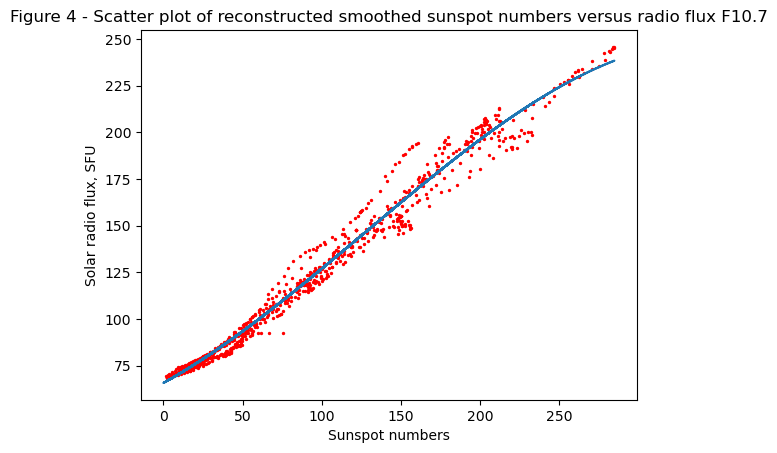

In [8]:
n=data_sol_clear.shape[0]
r=np.ones((n,4))
r[:,1]=data_sol_clear[:,2]
r[:,2]=data_sol_clear[:,2]**2
r[:,3]=data_sol_clear[:,2]**3
f=np.dot(r,beta)

# scatter plot of reconstructed smoothed monthly sunspot numbers & solar radio flux F10.7
plt.scatter(data_sol_clear[2434:,2],data_radio_clear[:,2], 2, 'r')
plt.xlabel('Sunspot numbers')
plt.ylabel('Solar radio flux, SFU')
plt.title('Figure 4 - Scatter plot of reconstructed smoothed sunspot numbers versus radio flux F10.7')
plt.plot(data_sol_clear[:,2], f)
plt.show()

So, after that we had dependence radio flux from monthly sunspot numbers, we can apply these coefficients for reconstructing radio flux. We visualize the results over the entire time period.

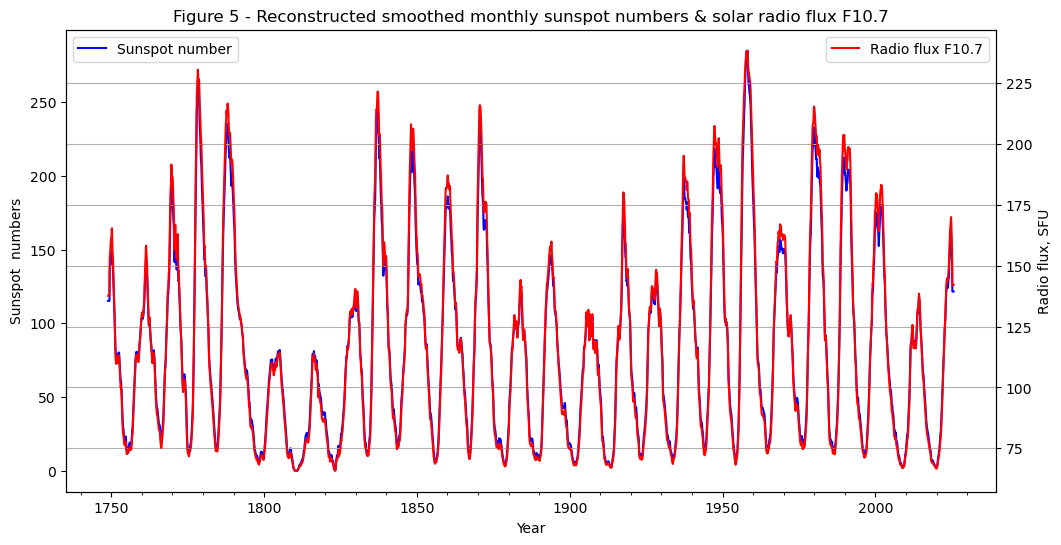

In [9]:
dates_sol = [datetime(int(year), int(month), 1) for year, month in zip(data_sol[:,0].astype(int), data_sol[:,1].astype(int))]
dates_rad = [datetime(int(year), int(month), 1) for year, month in zip(data_radio[:,0].astype(int), data_radio[:,1].astype(int))]

# plot of reconstructed smoothed monthly sunspot numbers & solar radio flux F10.7
plt.figure(figsize=(12,6))
plt.plot(dates_sol, data_sol_clear[:,2], color='blue', label='Sunspot number')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(50))    
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(10))    
plt.legend(loc='upper left')
plt.title('Figure 5 - Reconstructed smoothed monthly sunspot numbers & solar radio flux F10.7')
plt.xlabel('Year')
plt.ylabel('Sunspot  numbers')
ax2 = plt.gca().twinx()
ax2.plot(dates_sol,f,color='red', label='Radio flux F10.7')
ax2.set_ylabel('Radio flux, SFU')
ax2.legend(loc='upper right')
plt.grid()
plt.show()

Determining the root-mean square error (RMSE) of the reconstructed solar radio flux at 10.7 cm

In [10]:
def rmse(real_data, data):
    n = real_data.shape[0]
    sqrsum = 0
    for i in range(n):
        sqrsum += (real_data[i, 2] - data[i]) ** 2
    result = (sqrsum / (n - 1)) ** 0.5
    return result


error = rmse(data_radio_clear, f[2434:])
print(f'Root-mean square error: {error}')

Root-mean square error: 6.156692580077745


As we can see, the error is small, so the method works well. With more than 99% probability, the real value will be in the range of $±3\sigma$  of the estimated value.

Adding error bounds estimated as $±3\sigma$ and plotting reconstructed solar radio flux at 10.7 cm together with error ranges. 

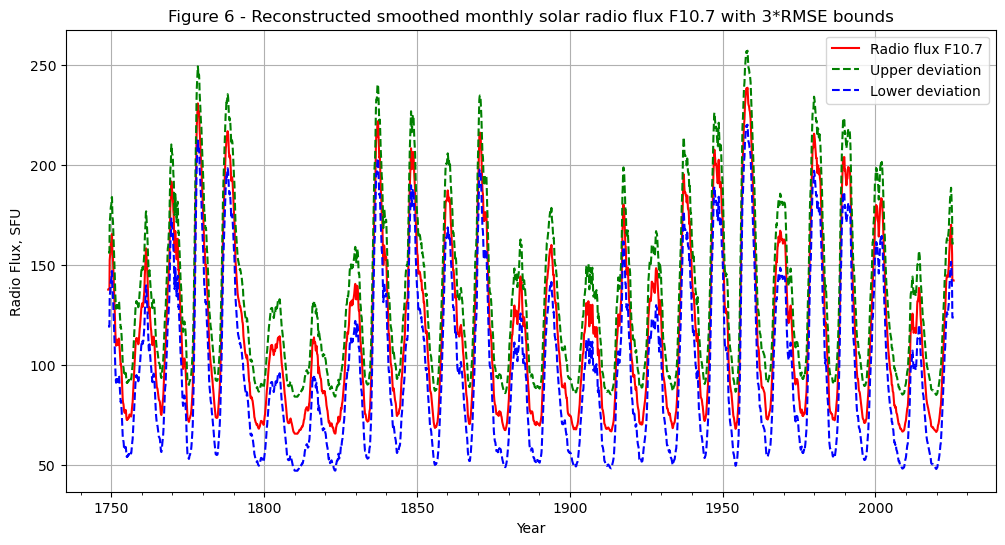

In [11]:
dates_sol = [datetime(int(year), int(month), 1) for year, month in zip(data_sol[:,0].astype(int), data_sol[:,1].astype(int))]
dates_rad = [datetime(int(year), int(month), 1) for year, month in zip(data_radio[:,0].astype(int), data_radio[:,1].astype(int))]
# plot of reconstructed smoothed monthly sunspot numbers & solar radio flux F10.7 with error ranges
plt.figure(figsize=(12,6))
plt.plot(dates_sol, f, color='red', label='Radio flux F10.7')
plt.plot(dates_sol, f + 3 * error, 'g--', label='Upper deviation')
plt.plot(dates_sol, f - 3 * error, 'b--', label='Lower deviation')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(50))    
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(10))    
plt.legend()
plt.title('Figure 6 - Reconstructed smoothed monthly solar radio flux F10.7 with 3*RMSE bounds')
plt.xlabel('Year')
plt.ylabel('Radio Flux, SFU')
plt.grid()
plt.show()

**Conclusion:**

Thus, we have found that if the mathematical model is known in advance and the quantities are truly dependent on each other, then we can reconstruct the data well. Thus, the least squares method is useful when the behavioral model is known, but is useless when it is unknown.

**Learning log:**

What we learned:

We learned how to use the least squares method to recover lost or unrecorded data from existing data. We also learned how to correctly apply this method from a mathematical perspective. Also, we learned in which cases linear regression and the least squares method can be used, and in which they will not lead to a result.
Also we learned how to apply running-mean smoothing to raw data.

What difficulties we faced:

We encountered difficulties with organizing our workflow and understanding data representation. The lack of experience in the practical application of statistical methods was a good incentive for a more detailed study of the material.
